## Libraries

In [1]:
import re
import string
import nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
import tensorflow as tf

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")


c:\Users\moham\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\moham\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

## Seeds

In [2]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Load Data

In [3]:
def load_data(path, file_type="csv", **kwargs):
    """
    Load a dataset from CSV or Excel.
    """
    
    if file_type == "csv":
        df = pd.read_csv(path, **kwargs)

    elif file_type in ["excel", "xlsx", "xls"]:
        df = pd.read_excel(path, **kwargs)

    else:
        raise ValueError("Unsupported file type. Use 'csv' or 'excel'.")

    return df

In [4]:
df = load_data(r"C:\Users\moham\Downloads\NLP_Cellula\NLP_Cellula_Internship\Week2\Task\LSTM\toxic_data_final.csv")

print(df.head())

                                         text  Toxic Category
0          A child playing in a sunny meadow.            Safe
1     A family enjoying a picnic in the park.            Safe
2          A child playing in a sunny meadow.            Safe
3  Police tape across a crime scene at night.  Violent Crimes
4          A child playing in a sunny meadow.            Safe


## Exploring Data

In [5]:
def explore_text_data(
    df,
    text_columns=None,
    target_column=None
):

    dataset_overview = pd.DataFrame({
        "Metric": [
            "Rows",
            "Columns",
            "Missing Values",
            "Duplicate Rows",
        ],
        "Value": [
            len(df),
            len(df.columns),
            df.isnull().sum().sum(),
            df.duplicated().sum(),
        ]
    })

    # Column information
    column_info = pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str).values,
        "Unique Values": df.nunique(dropna=False).values,
        "Missing Values": df.isnull().sum().values,
        "Missing %": (
            df.isnull().mean() * 100
        ).round(2).values
    })

    print("\n" + "=" * 70)
    print("DATASET OVERVIEW")
    print("=" * 70)

    display(dataset_overview)

    print("\n" + "=" * 70)
    print("Columns Information:")
    print("=" * 70)

    display(column_info)

# Text information
    text_info = None
    if text_columns is not None:

        if isinstance(text_columns, str):
            text_columns = [text_columns]

        text_results = []

        for column in text_columns:
            # Convert only for analysis
            text = df[column].fillna("").astype(str)

            char_length = text.str.len()
            word_count = text.str.split().str.len()

            empty_count = (text.str.strip() == "").sum()
            duplicate_texts = text.duplicated().sum()

            text_results.append({
                "Column": column,
                "Unique Texts": text.nunique(),
                "Empty Texts": empty_count,
                "Empty %": round(
                    empty_count / len(text) * 100, 2
                ),
                "Duplicate Texts": duplicate_texts,
                "Duplicate %": round(
                    duplicate_texts / len(text) * 100, 2
                ),
                "Min Characters": char_length.min(),
                "Max Characters": char_length.max(),
                "Min Words": word_count.min(),
                "Max Words": word_count.max(),
                "Mean Words": round(
                    word_count.mean(), 2
                ),
                "Median Words": round(
                    word_count.median(), 2
                )
            })

        if text_results:
            text_info = pd.DataFrame(text_results, columns=text_results[0].keys())

            print("\n" + "=" * 70)
            print("TEXT ANALYSIS")
            print("=" * 70)

            display(text_info)

# Target information
    target_info = None
    if target_column is not None:

        if target_column not in df.columns:
            print(f"\nWarning: '{target_column}' not found.")
        else:
            target = df[target_column]

            target_info = pd.DataFrame({
                "Class": target.value_counts(
                    dropna=False
                ).index.astype(str),

                "Count": target.value_counts(
                    dropna=False
                ).values,

                "Percentage": (
                    target.value_counts(
                        normalize=True,
                        dropna=False
                    ) * 100
                ).round(2).values
            })

            print("\n" + "=" * 70)
            print("TARGET ANALYSIS")
            print("=" * 70)

            print(f"\nTarget: {target_column}")
            print(
                f"Unique Classes: "
                f"{target.nunique(dropna=False)}"
            )
            print(
                f"Missing Targets: "
                f"{target.isnull().sum()}"
            )

            display(target_info)

    return dataset_overview, column_info, text_info, target_info

In [6]:
dataset_overview, column_info, text_info, target_info = explore_text_data(
    df,
    text_columns=["text"],
    target_column="Toxic Category"
)


DATASET OVERVIEW


,Metric,Value
0,Rows,7758
1,Columns,2
2,Missing Values,0
3,Duplicate Rows,3972



Columns Information:


,Column,Data Type,Unique Values,Missing Values,Missing %
0,text,str,3779,0,0.0
1,Toxic Category,str,9,0,0.0



TEXT ANALYSIS


,Column,Unique Texts,Empty Texts,Empty %,Duplicate Texts,Duplicate %,Min Characters,Max Characters,Min Words,Max Words,Mean Words,Median Words
0,text,3779,0,0.0,3979,51.29,12,761,2,140,10.93,10.0



TARGET ANALYSIS

Target: Toxic Category
Unique Classes: 9
Missing Targets: 0


,Class,Count,Percentage
0,Safe,1646,21.22
1,Violent Crimes,1610,20.75
2,Suicide & Self-Harm,1211,15.61
3,Child Sexual Exploitation,588,7.58
4,Sex-Related Crimes,578,7.45
5,Elections,568,7.32
6,Non-Violent Crimes,553,7.13
7,Unknown S-Type,504,6.50
8,unsafe,500,6.44


## Insights from the data

- first the data is ~2k rows after preprocessing
- data is unbalanced which will make a problem should handle it

## Data Cleaning

In [7]:
def Basic_clean_text(
    text,
    lowercase=True,
    remove_html=True,
    remove_urls=True,
    remove_emails=True,
    remove_mentions=True,
    remove_hashtags=True,
    remove_numbers=False,
    remove_punctuation=True,
    remove_extra_spaces=True,
    remove_newlines=True,
    remove_control_chars=True,
    normalize_repeated_chars=False,
    min_repeated_chars=3
):

    # Handle missing / invalid values
    if text is None:
        return ""

    if not isinstance(text, str):
        text = str(text)

    # Remove HTML
    if remove_html:
        text = re.sub(r"<[^>]+>", " ", text)

    # Remove / replace URLs
    if remove_urls:
        text = re.sub(
            r"https?://\S+|www\.\S+",
            " ",
            text
        )

    # Remove / replace emails
    if remove_emails:
        text = re.sub(
            r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b",
            " ",
            text
        )

    # Remove mentions
    if remove_mentions:
        text = re.sub(
            r"(?<!\w)@\w+",
            " ",
            text
        )

    # Handle hashtags
    if remove_hashtags:
        text = re.sub(
            r"(?<!\w)#\w+",
            " ",
            text
        )
    else:
        # Keep the hashtag word but remove '#'
        text = re.sub(
            r"#(\w+)",
            r"\1",
            text
        )

    # Remove numbers
    if remove_numbers:
        text = re.sub(r"\d+", " ", text)

    # Normalize repeated characters
    if normalize_repeated_chars:
        pattern = rf"(.)\1{{{min_repeated_chars},}}"
        text = re.sub(
            pattern,
            r"\1",
            text
        )

    # Remove punctuation
    if remove_punctuation:
        text = re.sub(
            r"[^\w\s]",
            " ",
            text,
            flags=re.UNICODE
        )

    # Remove newlines and tabs
    if remove_newlines:
        text = re.sub(r"[\r\n\t]+", " ", text)

    # Lowercase
    if lowercase:
        text = text.lower()

    # Normalize whitespace
    if remove_extra_spaces:
        text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

In [8]:
df["text"] = df["text"].apply(Basic_clean_text)

## Splittin data

In [9]:
df["Toxic Category"].value_counts()

Toxic Category
Safe                         1646
Violent Crimes               1610
Suicide & Self-Harm          1211
Child Sexual Exploitation     588
Sex-Related Crimes            578
Elections                     568
Non-Violent Crimes            553
Unknown S-Type                504
unsafe                        500
Name: count, dtype: int64

In [10]:
X = df["text"]
y = df["Toxic Category"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

## Tokenization

In [11]:
tokenizer = Tokenizer(
    num_words=300,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [12]:
print("Total vocabulary:", len(tokenizer.word_index))

Total vocabulary: 4375


In [13]:
oov_index = tokenizer.word_index["<OOV>"]

train_oov = sum(
    token == oov_index
    for seq in X_train
    for token in seq
)

total_tokens = sum(
    len(seq)
    for seq in X_train)

oov_percentage = (
    train_oov / total_tokens * 100
)

print(f"OOV percentage: {oov_percentage:.2f}%")

OOV percentage: 0.00%


In [14]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Get Max Len

In [15]:
lengths = X_train.apply(lambda x: len(x.split()))
print(lengths.describe())
print(lengths.quantile(0.95))

count    5430.000000
mean       11.150276
std         5.701344
min         3.000000
25%         8.000000
50%        11.000000
75%        13.000000
max       146.000000
Name: text, dtype: float64
17.0


In [16]:
lengths = pd.Series(
    [len(seq) for seq in X_train_seq]
)

print(lengths.describe())
print("90%:", lengths.quantile(0.90))
print("95%:", lengths.quantile(0.95))
print("99%:", lengths.quantile(0.99))

count    5430.000000
mean       11.150276
std         5.701344
min         3.000000
25%         8.000000
50%        11.000000
75%        13.000000
max       146.000000
dtype: float64
90%: 15.0
95%: 17.0
99%: 32.0


## Padding & Embedding

In [17]:
MAX_LEN = 28
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

In [18]:
EMBED_DIM = 128
embedding_layer = Embedding(input_dim=300, output_dim=EMBED_DIM, input_length=MAX_LEN, mask_zero=True)

## Target Encoding

In [19]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

num_classes = len(le.classes_)
print(le.classes_)

# save the label encoder for future use
import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

['Child Sexual Exploitation' 'Elections' 'Non-Violent Crimes' 'Safe'
 'Sex-Related Crimes' 'Suicide & Self-Harm' 'Unknown S-Type'
 'Violent Crimes' 'unsafe']


## Class Imbalance

In [20]:
classes = np.unique(y_train_enc)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, weights)
}

## Model Structure

In [21]:
model = Sequential([
    embedding_layer,
    Bidirectional(LSTM(64, return_sequences=False)),
    Dense(64, activation='relu'),    
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

In [22]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=1e-3,
    weight_decay=1e-4
)
model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

## Model Training

In [24]:
history = model.fit(
    X_train_pad,
    y_train_enc,

    validation_data=(
        X_val_pad,
        y_val_enc
    ),

    epochs=100,
    batch_size=64,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.4193 - loss: 1.8330 - val_accuracy: 0.6658 - val_loss: 0.7875 - learning_rate: 0.0010
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6737 - loss: 0.6222 - val_accuracy: 0.7337 - val_loss: 0.6571 - learning_rate: 0.0010
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7171 - loss: 0.5098 - val_accuracy: 0.7491 - val_loss: 0.6138 - learning_rate: 0.0010
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7382 - loss: 0.4663 - val_accuracy: 0.7655 - val_loss: 0.5888 - learning_rate: 0.0010
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7510 - loss: 0.4468 - val_accuracy: 0.7595 - val_loss: 0.5849 - learning_rate: 0.0010
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7577 - loss: 0.4290 - val_accuracy: 0.7620 - val_loss: 0.5878 - learning_rate: 0.0010
Epoch 7/100
83/85 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7667 - loss: 0.4092
Ep

## Model Evalaution

In [25]:
y_pred_prob = model.predict(X_test_pad)

y_train_pred = np.argmax(
    model.predict(X_train_pad, verbose=0),
    axis=1
)

y_val_pred = np.argmax(
    model.predict(X_val_pad, verbose=0),
    axis=1
)

y_test_pred = np.argmax(
    model.predict(X_test_pad, verbose=0),
    axis=1
)


37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


In [26]:
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred))

print(
    "Weighted F1:",
    f1_score(
        y_test_enc,
        y_test_pred,
        average="weighted"
    )
)

print(
    classification_report(
        y_test_enc,
        y_test_pred,
        target_names=le.classes_
    )
)

Accuracy: 0.770618556701031
Weighted F1: 0.7620262923443558
                           precision    recall  f1-score   support

Child Sexual Exploitation       0.99      0.99      0.99        89
                Elections       0.95      0.95      0.95        85
       Non-Violent Crimes       0.52      0.75      0.61        83
                     Safe       0.73      0.43      0.54       247
       Sex-Related Crimes       0.98      0.98      0.98        87
      Suicide & Self-Harm       0.72      1.00      0.84       182
           Unknown S-Type       0.73      0.69      0.71        75
           Violent Crimes       0.86      0.71      0.78       241
                   unsafe       0.60      0.91      0.72        75

                 accuracy                           0.77      1164
                macro avg       0.79      0.82      0.79      1164
             weighted avg       0.79      0.77      0.76      1164



## Confusion Matrix

In [27]:
cm_train = confusion_matrix(y_train_enc, y_train_pred)
cm_val = confusion_matrix(y_val_enc, y_val_pred)
cm_test = confusion_matrix(y_test_enc, y_test_pred)

class_names = le.classes_

In [28]:
def plot_confusion_matrix(cm, title):

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

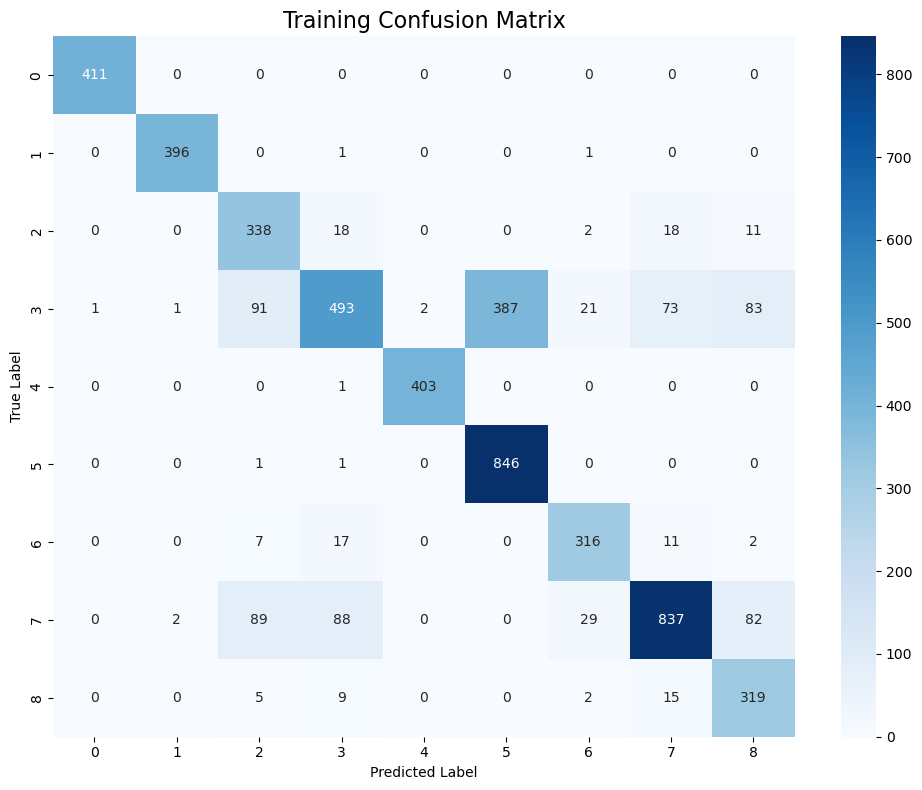

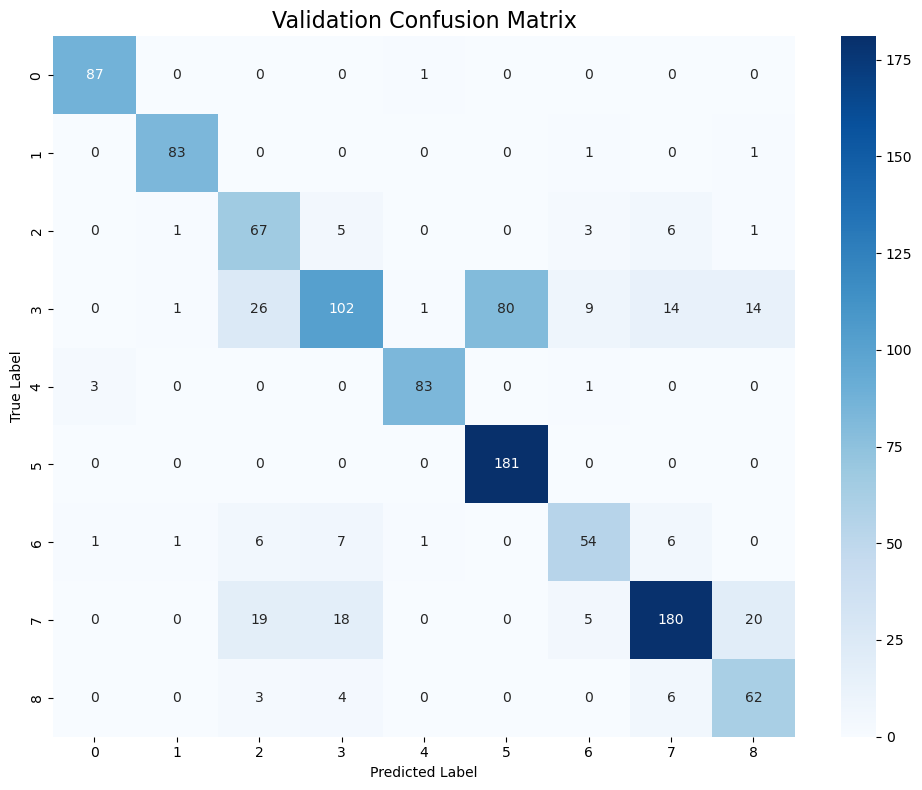

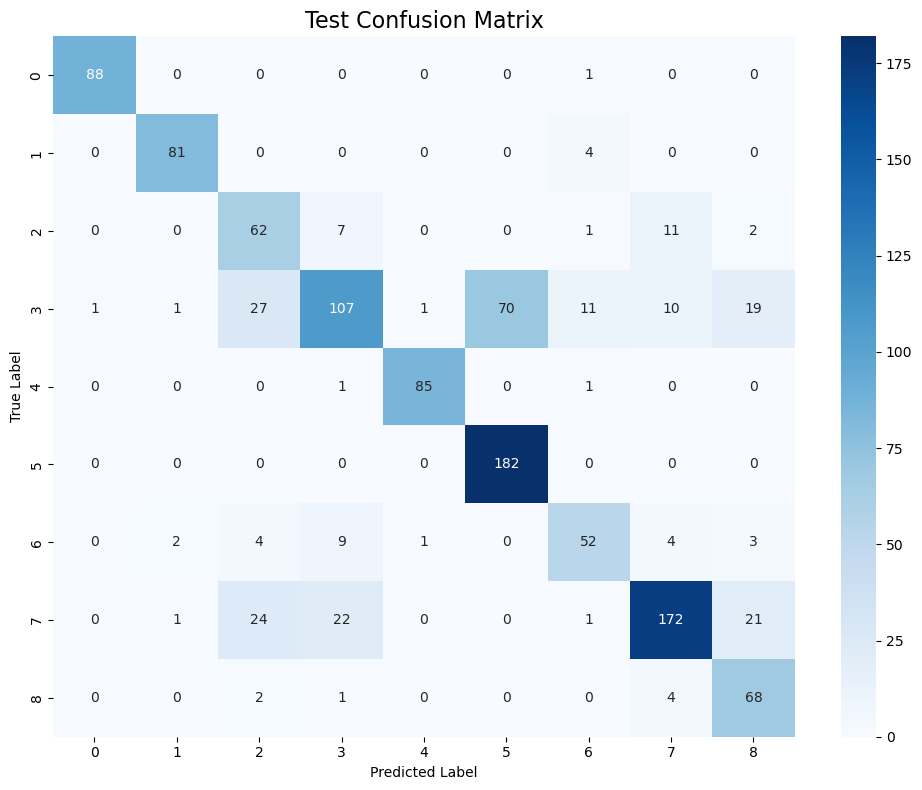

In [29]:
plot_confusion_matrix(cm_train, "Training Confusion Matrix")
plot_confusion_matrix(cm_val, "Validation Confusion Matrix")
plot_confusion_matrix(cm_test,"Test Confusion Matrix")

In [30]:
# save model for later use
model.save('lstm_model.keras')

In [31]:
import tensorflow as tf

model = tf.keras.models.load_model("lstm_model.keras")

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Enable optimization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Float16 quantization
converter.target_spec.supported_types = [tf.float16]

# Important for LSTM / Bidirectional LSTM
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open("lstm_model_float16.tflite", "wb") as f:
    f.write(tflite_model)

print("Conversion successful!")

INFO:tensorflow:Assets written to: C:\Users\moham\AppData\Local\Temp\tmpnvnvgvcf\assets


INFO:tensorflow:Assets written to: C:\Users\moham\AppData\Local\Temp\tmpnvnvgvcf\assets


Saved artifact at 'C:\Users\moham\AppData\Local\Temp\tmpnvnvgvcf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  2544338765392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2544519647248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2544519649552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2544519654736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2544519648784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2544519648976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2544519651472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2544519653392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2544519647440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2544338157392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2544338155856: 